# TFM — Primera aproximación: descarga, limpieza y exploración de datos Cerulean
## Golfo Pérsico y Mar Rojo

Este notebook es la **primera fase** del TFM: no entrena ningún modelo todavía. El objetivo es:

1. Descargar las detecciones de manchas de petróleo de **Cerulean (SkyTruth)** para golfo Pérsico y mar Rojo.
2. Limpiar y estructurar los datos.
3. Explorar y **comparar ambas zonas** (nº de detecciones, calidad, distribución temporal) para decidir con criterio cuál usar (o si usar ambas) como área de estudio definitiva.
4. Generar un primer **mapa de calor** (heatmap) como aproximación visual muy sencilla, previa a cualquier modelo predictivo formal.

**Antes de empezar:** no hace falta GPU para este notebook — con CPU va bien.

Ejecuta las celdas en orden. Si en la celda de descarga aparece un error de red, revisa primero
la celda de diagnóstico (sección 2) antes de seguir.

## 1. Instalación de dependencias

In [ ]:
!pip -q install requests geopandas shapely pandas matplotlib seaborn folium

import os
import time
import json
from pathlib import Path
from datetime import datetime, timezone

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Diagnóstico rápido de conexión con la API

Ejecuta esta celda primero. Si algo falla, el mensaje te dirá exactamente en qué paso
(conexión general, SSL, o la API concreta de Cerulean) para que sepas si el problema es tu red
o un parámetro mal formado.

In [ ]:
def diagnostico_conexion():
    print("-- - Test 1: conexión general a internet ---")
    try:
        r = requests.get("https://www.google.com", timeout=10)
        print(f"OK (status {r.status_code})")
    except Exception as e:
        print(f"FALLO: {type(e).__name__}: {e}")
        return False

    print("\n-- - Test 2: landing page de la API Cerulean ---")
    try:
        r = requests.get("https://api.cerulean.skytruth.org/", timeout=15)
        print(f"OK (status {r.status_code})")
    except Exception as e:
        print(f"FALLO: {type(e).__name__}: {e}")
        return False

    print("\n-- - Test 3: petición mínima a la colección de slicks_plus con API Key ---")
    try:
        from google.colab import userdata # Import inside function to ensure it's available
        CERULEAN_API_KEY = userdata.get('CERULEAN_API_KEY') # Get API key

        collection_to_test = "public.slick_plus" # Use the collection used in the rest of the notebook
        url = f"https://api.cerulean.skytruth.org/collections/{collection_to_test}/items"
        params = {"bbox": "47.5,23.5,56.5,30.5", "datetime": "2024-01-01T00:00:00Z/2024-02-01T00:00:00Z",
                   "limit": 5, "f": "json"}
        headers = {}
        if CERULEAN_API_KEY:
            headers['Authorization'] = f"Bearer {CERULEAN_API_KEY}"
            print("  (Usando CERULEAN_API_KEY)")
        else:
            print("  (CERULEAN_API_KEY no encontrada, intentando sin autenticación)")

        r = requests.get(url, params=params, headers=headers, timeout=30)
        print(f"Status: {r.status_code}")
        if r.status_code == 200:
            data = r.json()
            print(f"Features recibidas: {len(data.get('features', []))}")
        else:
            print(f"Cuerpo del error:\n{r.text[:500]}")
    except Exception as e:
        print(f"FALLO: {type(e).__name__}: {e}")
        return False

    print("\nTodo OK, puedes continuar con la descarga completa.")
    return True

diagnostico_conexion()

-- - Test 1: conexión general a internet ---
OK (status 200)

-- - Test 2: landing page de la API Cerulean ---
OK (status 200)

-- - Test 3: petición mínima a la colección de slicks_plus con API Key ---
FALLO: SecretNotFoundError: Secret CERULEAN_API_KEY does not exist.


False

## 3. Configuración de las zonas de estudio y periodo temporal

## 3.1. Configuración de la clave API de Cerulean

Para acceder a la API, necesitas una clave. Si no tienes una, por favor, obténla de Cerulean. Una vez que la tengas, guárdala de forma segura en los secretos de Colab bajo el nombre `CERULEAN_API_KEY`.

In [ ]:
# Importa la librería para gestionar secretos en Colab
from google.colab import userdata

# public.slick_plus es de lectura pública: si no hay clave, fetch_all_features
# sigue funcionando sin autenticación (solo se pierde el mapeo de nombres de
# fuente en la sección 10.1). Por eso ya no se aborta el notebook si falta la
# clave, solo se avisa.
try:
    CERULEAN_API_KEY = userdata.get('CERULEAN_API_KEY')
except Exception:
    CERULEAN_API_KEY = None

if not CERULEAN_API_KEY:
    print("[AVISO] CERULEAN_API_KEY no configurada. La descarga funciona igual sin ella "
          "(colección pública). Si más adelante quieres el mapeo de nombres de fuente "
          "(sección 10.1), añade la clave: icono de la llave en la barra lateral izquierda "
          "de Colab -> Add new secret -> nombre CERULEAN_API_KEY.")
else:
    print("Clave API de Cerulean configurada.")

In [ ]:
BASE_URL = "https://api.cerulean.skytruth.org"
COLLECTION = "public.slick_plus"

DATETIME_START = "2023-01-01T00:00:00Z"
DATETIME_END = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
DATETIME_RANGE = f"{DATETIME_START}/{DATETIME_END}"

# bbox = minLon, minLat, maxLon, maxLat
# Área fijada en Golfo Pérsico (se deja como dict de una sola zona para no
# tocar el resto del notebook, que ya itera sobre STUDY_AREAS.items()).
STUDY_AREAS = {
    "golfo_persico": (47.5, 23.5, 56.5, 30.5),
}

PAGE_LIMIT = 5000
MAX_RETRIES = 5
RETRY_WAIT_SECONDS = 5

OUTPUT_DIR = Path("/content/cerulean_data")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("Rango temporal:", DATETIME_RANGE)
print("Zonas configuradas:", list(STUDY_AREAS.keys()))

## 4. Función de descarga con paginación

In [ ]:
def fetch_all_features(bbox, datetime_range, verbose=True, max_pages=200):
    """Descarga TODAS las páginas de resultados para el bbox/rango dados.

    La API de Cerulean es OGC API Features: cada respuesta puede traer un
    array `links` con un elemento `rel == "next"` mientras queden más
    resultados. Si el servidor no expone ese link, se cae a paginación por
    `offset` incrementado en pasos de PAGE_LIMIT, parando cuando una página
    trae menos resultados que el límite pedido. Sin este bucle, cualquier
    bbox/rango con más de PAGE_LIMIT registros se trunca en silencio (es lo
    que pasaba antes: golfo_persico y mar_rojo se cortaban ambos en
    exactamente 5000 registros, muy por debajo del rango de fechas pedido).
    """
    url = f"{BASE_URL}/collections/{COLLECTION}/items"
    base_params = {
        "bbox": ",".join(map(str, bbox)),
        "datetime": datetime_range,
        "limit": PAGE_LIMIT,
        "f": "json",
    }

    headers = {}
    if 'CERULEAN_API_KEY' in globals() and CERULEAN_API_KEY:
        headers['Authorization'] = f"Bearer {CERULEAN_API_KEY}"
    elif verbose:
        print("  [WARN] CERULEAN_API_KEY no encontrada o no configurada. Intentando sin autenticación (puede fallar con 403).")

    features = []
    next_url, next_params = url, dict(base_params)
    offset = 0
    page = 0

    while next_url and page < max_pages:
        attempt = 0
        while True:
            try:
                resp = requests.get(next_url, params=next_params, headers=headers, timeout=60)
                resp.raise_for_status()
                data = resp.json()
                break
            except requests.exceptions.RequestException as e:
                attempt += 1
                if attempt > MAX_RETRIES:
                    print(f"  [ERROR] Fallo tras {MAX_RETRIES} intentos para {next_url}: {e}")
                    return features
                if verbose:
                    print(f"  [WARN] Error de red ({e}); reintentando ({attempt}/{MAX_RETRIES})...")
                time.sleep(RETRY_WAIT_SECONDS)

        if isinstance(data, list):
            page_features, links = data, []
        elif isinstance(data, dict) and "features" in data:
            page_features, links = data.get("features", []), data.get("links", [])
        else:
            print(f"  [ERROR] Formato de respuesta inesperado de la API ({next_url}). Tipo: {type(data)}")
            break

        features.extend(page_features)
        page += 1
        if verbose:
            print(f"  Página {page}: +{len(page_features)} registros (acumulado {len(features)})")

        next_link = next((l.get("href") for l in links if l.get("rel") == "next"), None)
        if next_link:
            next_url, next_params = next_link, None
        elif len(page_features) == PAGE_LIMIT:
            # El servidor no expone `next` pero la página vino llena: puede
            # haber más resultados. Se sigue paginando por offset.
            offset += PAGE_LIMIT
            next_url, next_params = url, dict(base_params, offset=offset)
        else:
            next_url = None

    if page >= max_pages and verbose:
        print(f"  [AVISO] Se alcanzó max_pages={max_pages}; puede que aún queden resultados sin descargar. Sube max_pages si hace falta.")

    if verbose:
        print(f"  Total registros recibidos: {len(features)}")

    return features

In [ ]:
# Esta celda contenía una definición duplicada de fetch_all_features y ha sido eliminada para evitar conflictos.
# La definición correcta ha sido actualizada en la celda vX98VIiAXTfa.

## 5. Descarga de las dos zonas

In [ ]:
raw_data = {}

for area_name, bbox in STUDY_AREAS.items():
    print(f"\n=== Descargando: {area_name} (bbox={bbox}) ===")
    features = fetch_all_features(bbox, DATETIME_RANGE)
    raw_data[area_name] = features
    print(f"  Total detecciones brutas: {len(features)}")

    # Chequeo de cordura: si la paginación funcionó, el rango de fechas
    # recibido debería acercarse al rango pedido (DATETIME_RANGE), no
    # cortarse muy por debajo como pasaba con el bug de paginación.
    timestamps = [
        f.get("properties", {}).get("slick_timestamp")
        for f in features
        if f.get("properties", {}).get("slick_timestamp")
    ]
    if timestamps:
        print(f"  Rango de fechas recibido: {min(timestamps)} -> {max(timestamps)}  (pedido: {DATETIME_START} -> {DATETIME_END})")

    raw_path = OUTPUT_DIR / f"raw_{area_name}.geojson"
    with open(raw_path, "w") as f:
        json.dump({"type": "FeatureCollection", "features": features}, f)
    print(f"  Guardado bruto: {raw_path}")

## 6. Conversión a GeoDataFrame y limpieza

Pasos de limpieza aplicados:
- Conversión a `GeoDataFrame` con geometría válida (se descartan geometrías nulas/corruptas).
- Parseo de `slick_timestamp` a datetime real.
- Eliminación de duplicados exactos (mismo `id`).
- Variables derivadas: año, mes, día de la semana, área aproximada en km².
- Se conserva `machine_confidence` sin filtrar todavía (la decisión de umbral se toma en la fase de EDA, no aquí, para no perder información antes de verla).

In [ ]:
import json
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import mapping

def clean_geodataframe(features, area_name):
    if not features:
        print(f"  [AVISO] Sin features para {area_name}.")
        return gpd.GeoDataFrame()

    cleaned_features_geojson = []
    for f in features:
        # Asegura que 'f' es un diccionario (representa una GeoJSON Feature)
        if not isinstance(f, dict):
            print(f"  [AVISO] Saltando elemento no-diccionario en features: {f}")
            continue

        original_geom = f.get("geometry")
        geom = original_geom

        # Si la geometría es una cadena, intenta parsearla como JSON o WKT
        if isinstance(geom, str):
            parsed = False
            # Intenta parsear como JSON
            try:
                geom = json.loads(geom)
                # No actualizamos f["geometry"] todavía, lo haremos en el GeoJSON final
                parsed = True
            except json.JSONDecodeError:
                pass # No es JSON, intenta WKT

            if not parsed:
                # Intenta parsear como WKT, manejando el prefijo SRID
                try:
                    wkt_string = geom
                    if wkt_string.startswith("SRID="):
                        # Eliminar el prefijo SRID=XXXX;
                        wkt_string = wkt_string.split(';', 1)[1]

                    shapely_geom = wkt.loads(wkt_string)
                    geom = mapping(shapely_geom) # Convierte Shapely a GeoJSON dict
                    parsed = True
                except Exception:
                    pass # No es WKT, ni JSON válido.

            if not parsed:
                print(f"  [AVISO] Geometría es cadena pero no JSON/WKT válido. ID: {f.get('id', 'N/A')}. Contenido: {original_geom[:200]}... Saltando.")
                continue # Salta esta feature si la cadena no es JSON/WKT válido

        # Asegura que la geometría es un diccionario (GeoJSON Geometry) o None
        if geom is None or isinstance(geom, dict):
            # Reestructurar la feature al formato GeoJSON estándar
            geojson_feature = {
                "type": "Feature",
                "geometry": geom,
                "properties": {k: v for k, v in f.items() if k != "geometry"}
            }
            cleaned_features_geojson.append(geojson_feature)
        else:
            print(f"  [AVISO] Feature con geometría de tipo inesperado ({type(geom)}). ID: {f.get('id', 'N/A')}. Saltando.")

    if not cleaned_features_geojson:
        print(f"  [AVISO] Sin features válidos con geometría de tipo diccionario/None para {area_name} después de filtrar.")
        return gpd.GeoDataFrame()

    gdf = gpd.GeoDataFrame.from_features(cleaned_features_geojson, crs="EPSG:4326")
    n_initial_valid = len(gdf)

    # Limpieza adicional de geometrías nulas o inválidas que pudieran haber pasado
    gdf = gdf[gdf.geometry.notnull() & gdf.geometry.is_valid]

    if "id" in gdf.columns:
        gdf = gdf.drop_duplicates(subset="id")

    n_after_cleaning = len(gdf)
    print(f"  {area_name}: {n_initial_valid} iniciales válidas -> {n_after_cleaning} registros tras limpieza geométrica y de duplicados")

    if "slick_timestamp" in gdf.columns:
        gdf["slick_timestamp"] = pd.to_datetime(gdf["slick_timestamp"], errors="coerce", utc=True)
        gdf["anio"] = gdf["slick_timestamp"].dt.year
        gdf["mes"] = gdf["slick_timestamp"].dt.month
        gdf["dia_semana"] = gdf["slick_timestamp"].dt.dayofweek

    try:
        # Proyectar a un CRS métrico para calcular el área con precisión
        gdf["area_km2_aprox"] = gdf.geometry.to_crs("ESRI:54034").area / 1e6
    except Exception as e:
        print(f"  [AVISO] No se pudo calcular área: {e}")

    # Calcular centroides en un CRS proyectado y luego reproyectarlos a EPSG:4326
    # para una mayor precisión en las coordenadas de latitud/longitud.
    try:
        projected_centroids = gdf.geometry.to_crs("ESRI:54034").centroid.to_crs(gdf.crs)
        gdf["centroid_lon"] = projected_centroids.x
        gdf["centroid_lat"] = projected_centroids.y
    except Exception as e:
        print(f"  [AVISO] No se pudo calcular centroides con precisión: {e}")
        # Fallback a cálculo directo si falla la proyección, aunque menos preciso
        gdf["centroid_lon"] = gdf.geometry.centroid.x
        gdf["centroid_lat"] = gdf.geometry.centroid.y

    gdf["zona_estudio"] = area_name

    return gdf


gdfs = {}
for area_name, features in raw_data.items():
    print(f"\nLimpiando: {area_name}")
    gdfs[area_name] = clean_geodataframe(features, area_name)


Limpiando: golfo_persico
  golfo_persico: 5000 iniciales válidas -> 5000 registros tras limpieza geométrica y de duplicados

Limpiando: mar_rojo
  mar_rojo: 5000 iniciales válidas -> 5000 registros tras limpieza geométrica y de duplicados


## 7. Comparativa entre zonas: ¿cuál tiene más/mejores datos?

In [ ]:
resumen = []
for area_name, gdf in gdfs.items():
    if gdf.empty:
        resumen.append({"zona": area_name, "n_detecciones": 0})
        continue

    resumen.append({
        "zona": area_name,
        "n_detecciones": len(gdf),
        "fecha_min": gdf["slick_timestamp"].min(),
        "fecha_max": gdf["slick_timestamp"].max(),
        "confianza_media": gdf["machine_confidence"].mean() if "machine_confidence" in gdf.columns else None,
        "pct_alta_confianza (>0.5)": (gdf["machine_confidence"] > 0.5).mean() * 100 if "machine_confidence" in gdf.columns else None,
        "area_km2_media": gdf["area_km2_aprox"].mean() if "area_km2_aprox" in gdf.columns else None,
    })

resumen_df = pd.DataFrame(resumen)
resumen_df

,zona,n_detecciones,fecha_min,fecha_max,confianza_media,pct_alta_confianza (>0.5),area_km2_media
0,golfo_persico,5000,2023-06-01 02:24:25+00:00,2024-11-17 02:15:52+00:00,0.812401,100.0,6.174360
1,mar_rojo,5000,2023-01-02 03:14:46+00:00,2025-05-30 03:37:45+00:00,0.802092,100.0,6.537653


In [ ]:
for area_name, gdf in gdfs.items():
    if gdf.empty:
        continue
    print(f"\n=== {area_name}: distribución de clase ===")
    # La API no devuelve una columna 'slick_class': la clasificación automática
    # está en 'cls' y la revisión humana (si existe) en 'hitl_cls_name'.
    if "cls" in gdf.columns:
        print("cls (clase automática):")
        print(gdf["cls"].value_counts(dropna=False))
    else:
        print("Columna 'cls' no presente; columnas disponibles:")
        print(list(gdf.columns))

    if "hitl_cls_name" in gdf.columns:
        print("\nhitl_cls_name (revisión humana, si existe):")
        print(gdf["hitl_cls_name"].value_counts(dropna=False))

    # Estas columnas ya traen una atribución de fuente/AOI calculada por
    # Cerulean (infraestructura, buque, evento natural...), relevante para la
    # pregunta 2 (concentración cerca de rutas/terminales) antes incluso de
    # cruzar con capas externas de tráfico e infraestructura.
    for col in ["aoi_type_1_ids", "source_type_1_ids"]:
        if col in gdf.columns:
            n_non_null = gdf[col].notna().sum()
            print(f"\n{col}: {n_non_null}/{len(gdf)} registros con atribución")

## 8. Detecciones por año/mes (para ver si hay suficiente serie temporal)

In [ ]:
n_areas = len(gdfs)
fig, axes = plt.subplots(1, n_areas, figsize=(7 * n_areas, 4), sharey=False)
if n_areas == 1:
    axes = [axes]

for ax, (area_name, gdf) in zip(axes, gdfs.items()):
    if gdf.empty or "slick_timestamp" not in gdf.columns:
        ax.set_title(f"{area_name} (sin datos)")
        continue
    monthly = gdf.set_index("slick_timestamp").resample("ME").size()
    monthly.plot(ax=ax, marker="o")
    ax.set_title(f"Detecciones por mes — {area_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Nº detecciones")

plt.tight_layout()
plt.show()

## 9. Decisión de zona de estudio

Con la tabla resumen y los gráficos anteriores, decide:
- Si una zona tiene claramente más volumen y mejor calidad (más `machine_confidence` alta), esa es tu candidata natural.
- Si ambas tienen un volumen razonable, puedes optar por combinarlas en un único dataset (columna `zona_estudio` ya te permite diferenciarlas después) para tener más muestra.

La siguiente celda combina ambos GeoDataFrames en uno solo, por si decides usar las dos zonas.

In [ ]:
gdf_combined = pd.concat([g for g in gdfs.values() if not g.empty], ignore_index=True)
gdf_combined = gpd.GeoDataFrame(gdf_combined, geometry="geometry", crs="EPSG:4326")
print(f"Total combinado: {len(gdf_combined)} detecciones")
gdf_combined.head()

Total combinado: 10000 detecciones


/tmp/ipykernel_628/3046654977.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gdf_combined = pd.concat([g for g in gdfs.values() if not g.empty], ignore_index=True)


,geometry,collectionId,itemId,id,slick_timestamp,machine_confidence,slick_confidence,length,area,perimeter,polsby_popper,fill_factor,centerlines,aspect_ratio_factor,cls,orchestrator_run,linearity,s1_scene_id,hitl_cls,hitl_cls_name,aoi_type_1_ids,aoi_type_2_ids,aoi_type_3_ids,source_type_1_ids,source_type_2_ids,source_type_3_ids,max_source_collated_score,slick_url,anio,mes,dia_semana,area_km2_aprox,centroid_lon,centroid_lat,zona_estudio
0,"MULTIPOLYGON (((51.84448 27.63886, 51.84517 27...",public.slick_plus,3000373,3000373,2024-09-08 14:34:12+00:00,0.863416,NaN,20112.315310,7.599346e+06,66948.527787,0.021306,0.052612,"{'type': 'FeatureCollection', 'features': [{'i...",0.271261,5,124,2498.296134,S1A_IW_GRDH_1SDV_20240908T143412_20240908T1434...,NaN,None,[165],[321],None,None,None,None,NaN,https://cerulean.skytruth.org/slicks/3000373?r...,2024,9,6,7.599340,51.758482,27.653075,golfo_persico
1,"MULTIPOLYGON (((51.38306 27.66907, 51.38718 27...",public.slick_plus,3000374,3000374,2024-09-08 14:34:12+00:00,0.758456,NaN,44991.521626,1.192865e+07,144400.145796,0.007189,0.018816,"{'type': 'FeatureCollection', 'features': [{'i...",0.283345,4,124,23605.027230,S1A_IW_GRDH_1SDV_20240908T143412_20240908T1434...,NaN,None,[165],[321],None,None,None,None,NaN,https://cerulean.skytruth.org/slicks/3000374?r...,2024,9,6,11.928648,51.282925,27.709289,golfo_persico
2,"MULTIPOLYGON (((52.20634 27.40059, 52.20703 27...",public.slick_plus,3000375,3000375,2024-09-08 14:34:12+00:00,0.758828,NaN,60137.241111,2.146886e+07,254357.019174,0.004170,0.018271,"{'type': 'FeatureCollection', 'features': [{'i...",0.324702,3,124,40396.769444,S1A_IW_GRDH_1SDV_20240908T143412_20240908T1434...,NaN,None,[165],[321],None,None,None,None,NaN,https://cerulean.skytruth.org/slicks/3000375?r...,2024,9,6,21.468861,51.859933,27.373711,golfo_persico
3,"MULTIPOLYGON (((52.37042 27.4809, 52.37111 27....",public.slick_plus,3000376,3000376,2024-09-08 14:34:12+00:00,0.681512,NaN,44853.926812,2.797924e+06,59184.731664,0.010038,0.003843,"{'type': 'FeatureCollection', 'features': [{'i...",0.519631,3,124,71637.183078,S1A_IW_GRDH_1SDV_20240908T143412_20240908T1434...,NaN,None,[165],[321],None,None,[1056308],"[D214.551224, D198.973434, D184.089783, D198.2...",-0.343426,https://cerulean.skytruth.org/slicks/3000376?r...,2024,9,6,2.797919,52.190624,27.507501,golfo_persico
4,"MULTIPOLYGON (((51.75382 27.50562, 51.7545 27....",public.slick_plus,3000377,3000377,2024-09-08 14:34:12+00:00,0.726640,NaN,66003.757427,9.185420e+06,131325.441567,0.006693,0.006477,"{'type': 'FeatureCollection', 'features': [{'i...",0.465747,5,124,70864.237331,S1A_IW_GRDH_1SDV_20240908T143412_20240908T1434...,NaN,None,[165],[321],None,"[422297500, 422204800]",None,"[D91.4716797, D44.7651901, D37.9694824, D89.06...",-1.063977,https://cerulean.skytruth.org/slicks/3000377?r...,2024,9,6,9.185426,51.427845,27.669984,golfo_persico


## 8.1 Rejilla espacio-temporal: el lado "positivo" del esfuerzo de observación

Para responder con rigor las preguntas 3 y 4 de la hoja de ruta (¿cuánto del patrón
observado es cobertura del satélite y cuánto incidencia real?; modelo predictivo de
probabilidad de detección) no basta con la tabla de eventos: hace falta saber también
**dónde y cuándo hubo una pasada de Sentinel-1 que no encontró ninguna mancha**.

Esta celda construye la mitad "positiva" de esa tabla: una rejilla espacial sobre cada
zona y, para cada detección, la celda a la que pertenece su centroide. El resultado
(`positivos_celda_escena.csv`) se cruza más adelante, en el notebook de emparejamiento
óptico (sección 9), con el catálogo completo de escenas Sentinel-1 sobre el AOI
(incluidas las que no tienen ninguna mancha), usando el mismo `cell_id` — por eso
`CELL_KM` y el bbox de cada zona deben coincidir entre los dos notebooks.

In [ ]:
# Rejilla espacio-temporal (Fase 3 de la metodología). CELL_KM y el bbox de
# cada zona (STUDY_AREAS) deben coincidir exactamente con los usados en la
# sección 9 del notebook de emparejamiento óptico para que los cell_id sean
# comparables entre los dos notebooks.
import numpy as np
from shapely.geometry import box

CELL_KM = 10  # lado de la celda en km; ajustar según densidad de datos

def build_grid(bbox, cell_km=CELL_KM):
    minx, miny, maxx, maxy = bbox
    lat_mid = (miny + maxy) / 2
    dlat = cell_km / 111.0
    dlon = cell_km / (111.0 * np.cos(np.radians(lat_mid)))
    xs = np.arange(minx, maxx, dlon)
    ys = np.arange(miny, maxy, dlat)
    rows = []
    for i, x in enumerate(xs):
        for j, y in enumerate(ys):
            rows.append({
                "cell_id": f"{i}_{j}",
                "geometry": box(x, y, x + dlon, y + dlat),
            })
    return gpd.GeoDataFrame(rows, crs="EPSG:4326")


grids = {area_name: build_grid(bbox) for area_name, bbox in STUDY_AREAS.items()}
for area_name, grid in grids.items():
    print(f"{area_name}: rejilla de {len(grid)} celdas de ~{CELL_KM} km de lado")

# Asignar cada detección (por su centroide) a la celda de su zona
gdf_combined["cell_id"] = None
for area_name, grid in grids.items():
    mask = gdf_combined["zona_estudio"] == area_name
    pts = gpd.GeoDataFrame(
        gdf_combined.loc[mask, ["centroid_lon", "centroid_lat"]],
        geometry=gpd.points_from_xy(gdf_combined.loc[mask, "centroid_lon"], gdf_combined.loc[mask, "centroid_lat"]),
        crs="EPSG:4326",
    )
    joined = gpd.sjoin(pts, grid[["cell_id", "geometry"]], how="left", predicate="within")
    gdf_combined.loc[mask, "cell_id"] = joined["cell_id"].values

print(f"\nDetecciones sin celda asignada (fuera de la rejilla): {gdf_combined['cell_id'].isna().sum()}")

# Tabla positiva lista para el modelo de esfuerzo: nº de detecciones por celda-escena.
# Las filas "negativas" (pasadas de S1 sin detección) se añaden en el notebook de
# emparejamiento óptico, sección 9, cruzando por el mismo cell_id + s1_scene_id.
positives_panel = (
    gdf_combined.dropna(subset=["cell_id"])
    .groupby(["zona_estudio", "cell_id", "s1_scene_id"])
    .size()
    .reset_index(name="n_events")
)
positives_panel.to_csv(OUTPUT_DIR / "positivos_celda_escena.csv", index=False)
for area_name, grid in grids.items():
    grid.to_file(OUTPUT_DIR / f"rejilla_{area_name}.geojson", driver="GeoJSON")

print(f"\nGuardado: positivos_celda_escena.csv ({len(positives_panel)} filas) y una rejilla GeoJSON por zona en {OUTPUT_DIR}")
print("Sube 'positivos_celda_escena.csv' al notebook de emparejamiento óptico (sección 9) para completar el panel con las pasadas sin detección.")

## 10.1. Mapear IDs de Fuentes a Nombres

In [ ]:
# Definir la colección para las fuentes
SOURCE_COLLECTION = "public.source"

def fetch_all_sources(verbose=True, max_pages=50):
    """Descarga todas las páginas de la colección de fuentes (mismo patrón de
    paginación por `links[rel=next]` / `offset` que fetch_all_features)."""
    url = f"{BASE_URL}/collections/{SOURCE_COLLECTION}/items"
    base_params = {"limit": 1000, "f": "json"}

    headers = {}
    if 'CERULEAN_API_KEY' in globals() and CERULEAN_API_KEY:
        headers['Authorization'] = f"Bearer {CERULEAN_API_KEY}"
    else:
        print("  [ERROR] CERULEAN_API_KEY no encontrada o no configurada. Configura la clave API en los secretos de Colab y ejecuta la celda 3.1.")
        return []

    sources = []
    next_url, next_params = url, dict(base_params)
    offset = 0
    page = 0

    while next_url and page < max_pages:
        attempt = 0
        while True:
            try:
                resp = requests.get(next_url, params=next_params, headers=headers, timeout=60)
                resp.raise_for_status()
                data = resp.json()
                break
            except requests.exceptions.RequestException as e:
                attempt += 1
                if attempt > MAX_RETRIES:
                    print(f"  [ERROR] Fallo tras {MAX_RETRIES} intentos para {next_url}: {e}")
                    return sources
                if verbose:
                    print(f"  [WARN] Error de red ({e}); reintentando ({attempt}/{MAX_RETRIES})...")
                time.sleep(RETRY_WAIT_SECONDS)

        if isinstance(data, list):
            page_sources, links = data, []
        elif isinstance(data, dict) and "features" in data:
            page_sources, links = data.get("features", []), data.get("links", [])
        else:
            print(f"  [ERROR] Formato de respuesta inesperado de la API ({next_url}). Tipo: {type(data)}")
            break

        sources.extend(page_sources)
        page += 1
        if verbose:
            print(f"  Página {page}: +{len(page_sources)} fuentes (acumulado {len(sources)})")

        next_link = next((l.get("href") for l in links if l.get("rel") == "next"), None)
        if next_link:
            next_url, next_params = next_link, None
        elif len(page_sources) == base_params["limit"]:
            offset += base_params["limit"]
            next_url, next_params = url, dict(base_params, offset=offset)
        else:
            next_url = None

    if verbose:
        print(f"  Total fuentes recibidas: {len(sources)}")

    return sources

print("Descargando fuentes de Cerulean...")
raw_sources = fetch_all_sources()

# Procesar las fuentes para crear un diccionario de mapeo ID -> Nombre
source_id_to_name = {}
for s in raw_sources:
    if isinstance(s, dict) and 'id' in s and 'properties' in s and 'name' in s['properties']:
        source_id_to_name[str(s['id'])] = s['properties']['name']
    elif isinstance(s, dict) and 'id' in s and 'name' in s:
         source_id_to_name[str(s['id'])] = s['name'] # Si 'name' está directamente en el nivel superior

print(f"Mapeadas {len(source_id_to_name)} fuentes.")

# Función para mapear una lista de IDs a una lista de nombres
def map_source_ids_to_names(id_list, id_to_name_map):
    if not isinstance(id_list, list):
        return None # O un string vacío, dependiendo de cómo quieras manejar los NaN

    # Convertir todos los IDs de la lista a string para la búsqueda
    return [id_to_name_map.get(str(item), item) for item in id_list]


# Aplicar el mapeo a las columnas relevantes en gdf_combined
for col_name in ['source_type_1_ids', 'source_type_2_ids', 'source_type_3_ids']:
    if col_name in gdf_combined.columns:
        new_col_name = col_name.replace('_ids', '_names')
        print(f"Mapeando {col_name} a {new_col_name}...")
        # Usar .loc para evitar SettingWithCopyWarning
        gdf_combined.loc[:, new_col_name] = gdf_combined[col_name].apply(lambda x: map_source_ids_to_names(x, source_id_to_name))

# Mostrar las nuevas columnas (y las originales para comparación)
print("\nColumnas de fuentes con nombres:")
display(gdf_combined[['source_type_1_ids', 'source_type_1_names',
                      'source_type_2_ids', 'source_type_2_names',
                      'source_type_3_ids', 'source_type_3_names']].head())

## 10. Primer mapa de calor (heatmap) — aproximación visual, no un modelo todavía

Dos versiones:
1. Un `heatmap` estático con Seaborn/Matplotlib (rápido, sirve para la memoria del TFM).
2. Un mapa interactivo con Folium (útil para explorar tú mismo, exportable a `.html`).

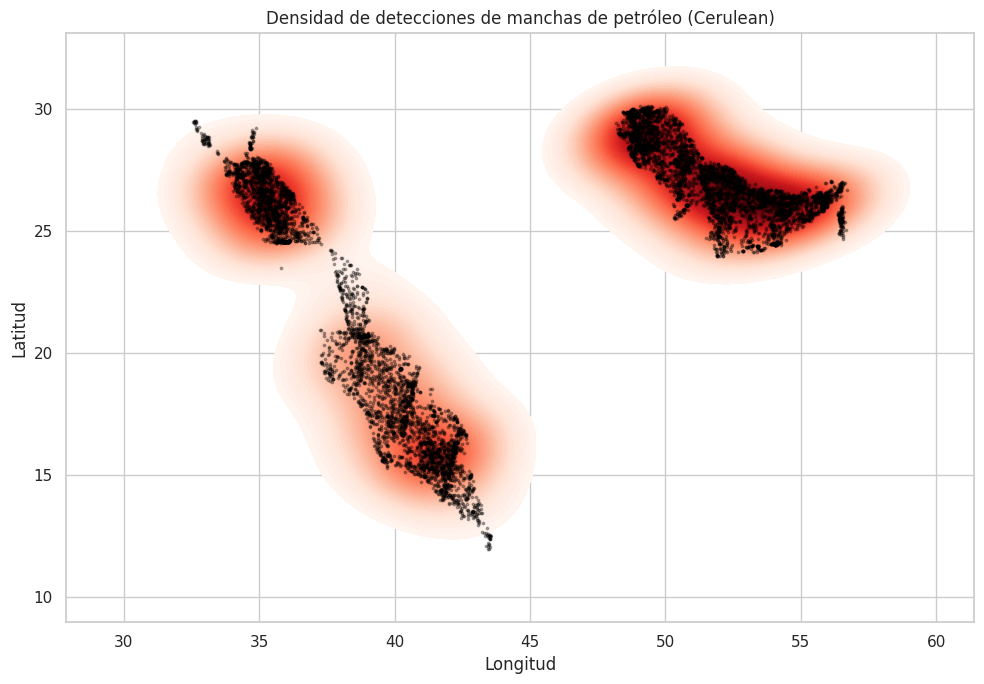

In [ ]:
if gdf_combined.empty:
    print("No hay datos válidos para generar el heatmap estático.")
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.text(0.5, 0.5, "No hay datos para mostrar", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=16)
    ax.set_title("Densidad de detecciones de manchas de petróleo (Cerulean)")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.savefig("/content/heatmap_estatico.png", dpi=200)
    plt.show()
else:
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    sns.kdeplot(
        data=gdf_combined,
        x="centroid_lon", y="centroid_lat",
        fill=True, cmap="Reds", thresh=0.05, levels=50, ax=ax
    )
    ax.scatter(gdf_combined["centroid_lon"], gdf_combined["centroid_lat"], s=3, color="black", alpha=0.3)
    ax.set_title("Densidad de detecciones de manchas de petróleo (Cerulean)")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.savefig("/content/heatmap_estatico.png", dpi=200)
    plt.show()

In [ ]:
if gdf_combined.empty:
    print("No hay datos válidos para generar el mapa de calor interactivo.")
    # Crear un mapa vacío con un mensaje
    m = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB positron")
    folium.Marker(
        location=[0, 0],
        icon=folium.DivIcon(html="<div style='font-size: 14pt; color: red;'>No hay datos para mostrar</div>")
    ).add_to(m)
    m.save("/content/heatmap_interactivo.html")
    # Usar display() para mostrar el mapa en Colab si no hay datos
    from IPython.display import display
    display(m)
else:
    center_lat = gdf_combined["centroid_lat"].mean()
    center_lon = gdf_combined["centroid_lon"].mean()

    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles="CartoDB positron")

    heat_data = gdf_combined[["centroid_lat", "centroid_lon"]].dropna().values.tolist()
    HeatMap(heat_data, radius=10, blur=15).add_to(m)

    m.save("/content/heatmap_interactivo.html")
    m

## 11. Guardar los datos limpios (para la siguiente fase: modelo predictivo)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

OUT_DIR = "/content/drive/MyDrive/TFM_vertidos/datos_limpios"
os.makedirs(OUT_DIR, exist_ok=True)

# Guardar GDFs individuales
for area_name, gdf in gdfs.items():
    if not gdf.empty: # Comprobar si el gdf no está vacío
        gdf.to_file(os.path.join(OUT_DIR, f"cerulean_{area_name}_limpio.geojson"), driver="GeoJSON")
        df_csv = gdf.drop(columns="geometry")
        df_csv.to_csv(os.path.join(OUT_DIR, f"cerulean_{area_name}_limpio.csv"), index=False)
    else:
        print(f"  [AVISO] No hay datos válidos para {area_name}. No se guardará el archivo.")

# Guardar GDF combinado
if not gdf_combined.empty: # Comprobar si gdf_combined no está vacío
    gdf_combined.drop(columns="geometry").to_csv(os.path.join(OUT_DIR, "cerulean_combinado.csv"), index=False)
    gdf_combined.to_file(os.path.join(OUT_DIR, "cerulean_combinado.geojson"), driver="GeoJSON")
else:
    print("  [AVISO] No hay datos combinados válidos. No se guardará el archivo combinado.")

# Guardar archivos de imagen y html (estos pueden generarse incluso si los datos están vacíos, con un marcador de posición)
# Suponiendo que heatmap_estatico.png y heatmap_interactivo.html siempre se generan, incluso si están vacíos
if os.path.exists("/content/heatmap_estatico.png"):
    shutil.copy("/content/heatmap_estatico.png", OUT_DIR)
else:
    print("  [AVISO] No se encontró 'heatmap_estatico.png' para guardar.")
if os.path.exists("/content/heatmap_interactivo.html"):
    shutil.copy("/content/heatmap_interactivo.html", OUT_DIR)
else:
    print("  [AVISO] No se encontró 'heatmap_interactivo.html' para guardar.")

# resumen_df debería existir y no estar vacío, ya que siempre se crea con al menos las zonas y n_detecciones = 0
resumen_df.to_csv(os.path.join(OUT_DIR, "resumen_comparativo_zonas.csv"), index=False)

print("Guardado en:", OUT_DIR)
print("\nArchivos generados:")
if os.path.exists(OUT_DIR):
    for f in os.listdir(OUT_DIR):
        print(" -", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Guardado en: /content/drive/MyDrive/TFM_vertidos/datos_limpios

Archivos generados:
 - cerulean_golfo_persico_limpio.geojson
 - cerulean_golfo_persico_limpio.csv
 - cerulean_mar_rojo_limpio.geojson
 - cerulean_mar_rojo_limpio.csv
 - cerulean_combinado.csv
 - cerulean_combinado.geojson
 - heatmap_estatico.png
 - heatmap_interactivo.html
 - resumen_comparativo_zonas.csv


In [ ]:
## Próximos pasos (siguiente notebook)

Con esta primera aproximación ya tienes:
- Los datos descargados **sin el techo de 5000 registros** (paginación arreglada en la sección 4) de ambas zonas.
- Una decisión informada sobre la(s) zona(s) de estudio definitiva(s).
- Un primer heatmap visual.
- La rejilla espacio-temporal y la tabla de eventos por celda (`positivos_celda_escena.csv`, sección 8.1), lista para cruzarse con el catálogo de esfuerzo.

El notebook de emparejamiento óptico (`optical_dataset_colab.ipynb`) ya incluye, en su sección 9,
el catálogo de **todas** las pasadas de Sentinel-1 sobre el AOI (con y sin detección) y el cruce con
`positivos_celda_escena.csv` para producir el panel celda-mes con exposición (`n_pases`) — la entrada
directa para el modelo explicativo con offset de esfuerzo (GLM Poisson/binomial negativa) y, después,
el modelo predictivo (Random Forest / XGBoost) sobre esa misma rejilla.

## Próximos pasos (siguiente notebook)

Con esta primera aproximación ya tienes:
- Los datos descargados y limpios de ambas zonas.
- Una decisión informada sobre la(s) zona(s) de estudio definitiva(s).
- Un primer heatmap visual.

El siguiente notebook (cuando quieras continuar) puede abordar el **modelo predictivo formal**:
discretización en una rejilla espacio-temporal, variables explicativas (distancia a rutas de tráfico,
distancia a infraestructura, historial previo, estacionalidad) y un modelo de clasificación/conteo
(Random Forest, regresión logística espacial, o un GLM de Poisson) sobre esa rejilla.